In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds


### Importar librerías
Se importan TensorFlow para construir y entrenar el modelo, y TensorFlow Datasets para cargar el conjunto de datos Fashion MNIST.

In [ ]:
datos, metadatos = tfds.load('mnist', as_supervised=True, with_info=True)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.955TLR_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.955TLR_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


### Cargar el conjunto de datos Fashion MNIST
Se carga el dataset 'fashion_mnist' de TensorFlow Datasets. `as_supervised=True` asegura que los datos se devuelvan como tuplas (imagen, etiqueta) y `with_info=True` permite acceder a los metadatos del dataset.

In [ ]:
metadatos

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/root/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year

### Mostrar metadatos del dataset
Aquí se imprimen los metadatos del dataset, que incluyen información como el nombre, descripción, formato de archivo, tamaño y la estructura de las características (imágenes y etiquetas).

In [ ]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

### Dividir el dataset en conjuntos de entrenamiento y prueba
Se asignan los datos de entrenamiento y prueba a variables separadas para facilitar su uso.

In [ ]:
nombres_clases = metadatos.features['label'].names
print("Nombres de las clases: ", nombres_clases)

Nombres de las clases:  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


### Obtener y mostrar los nombres de las clases
Se extraen los nombres de las clases de las etiquetas del dataset y se imprimen. Esto nos permite saber a qué corresponden los números de las etiquetas (por ejemplo, 0 es 'T-shirt/top', 1 es 'Trouser', etc.).

In [ ]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    etiquetas = tf.cast(etiquetas, tf.int64) # Ensure labels are int64
    etiquetas = tf.reshape(etiquetas, []) # Ensure labels are scalar
    return imagenes, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

### Función de normalización y preprocesamiento de datos
La función `normalizar` convierte las imágenes a tipo `float32` y las escala dividiéndolas por 255 para que sus valores estén en el rango de 0 a 1. También asegura que las etiquetas sean de tipo `int64` y escalares. Luego, aplica esta función a los conjuntos de entrenamiento y prueba y los cachea para un acceso más rápido durante el entrenamiento.

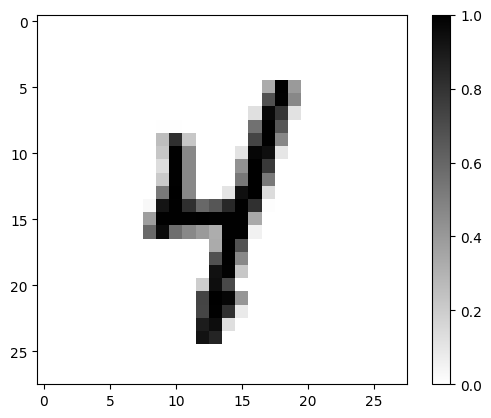

In [ ]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break


import matplotlib.pyplot as plt
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.show()

### Visualizar una imagen de ejemplo
Se toma una imagen del conjunto de entrenamiento y se muestra utilizando `matplotlib`. La barra de color a la derecha indica la intensidad de los píxeles.

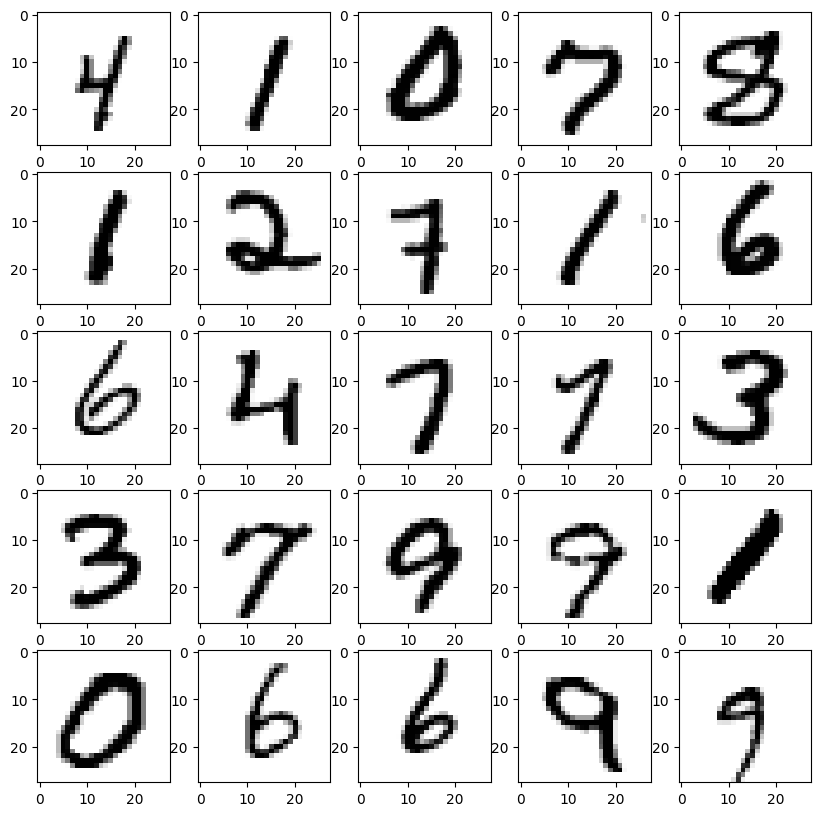

In [ ]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  plt.subplot(5,5,i+1)
  plt.imshow(imagen, cmap=plt.cm.binary)

plt.show()

### Visualizar varias imágenes de ejemplo
Se muestran 25 imágenes del conjunto de entrenamiento en una cuadrícula de 5x5, utilizando el mapa de color binario para una mejor visualización de las prendas.

In [ ]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Definición del modelo de red neuronal
Se construye un modelo `Sequential` de Keras con las siguientes capas:
- `Flatten`: Transforma las imágenes de 28x28 píxeles a un vector de 784 píxeles.
- `Dense` (50 neuronas, activación ReLU): Capa oculta fully connected.
- `Dense` (50 neuronas, activación ReLU): Segunda capa oculta fully connected.
- `Dense` (10 neuronas, activación Softmax): Capa de salida con 10 neuronas (una por cada clase) y función de activación softmax para obtener probabilidades de clase.

In [ ]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

### Compilación del modelo
Se compila el modelo con:
- `optimizer='adam'`: Algoritmo de optimización Adam.
- `loss=tf.keras.losses.SparseCategoricalCrossentropy()`: Función de pérdida adecuada para clasificación multiclase con etiquetas enteras.
- `metrics=['accuracy']`: Métrica de evaluación para monitorear la precisión durante el entrenamiento.

In [ ]:
TAMAND_LOTE = 32

datos_entrenamiento = datos_entrenamiento.repeat().shuffle(60000).batch(TAMAND_LOTE)
datos_pruebas = datos_pruebas.batch(TAMAND_LOTE)

### Configuración de los datos de entrenamiento y prueba
Se define el tamaño del lote (`TAMAND_LOTE`). Los datos de entrenamiento se repiten, se mezclan aleatoriamente y se dividen en lotes. Los datos de prueba solo se dividen en lotes.

In [ ]:
import math

entrenamiento = modelo.fit(datos_entrenamiento, epochs=10, steps_per_epoch=math.ceil(60000/TAMAND_LOTE))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9138 - loss: 0.2973
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9573 - loss: 0.1418
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9687 - loss: 0.1030
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9751 - loss: 0.0819
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9783 - loss: 0.0694
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9818 - loss: 0.0565
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9841 - loss: 0.0492
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9855 - loss: 0.0442
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9872 - loss: 0.0402
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9896 - loss: 0.0319


### Entrenamiento del modelo
Se entrena el modelo utilizando los datos de entrenamiento. Se especifica el número de `epochs` (pasadas completas sobre el dataset) y `steps_per_epoch` para indicar cuántos pasos de entrenamiento se realizan por época.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


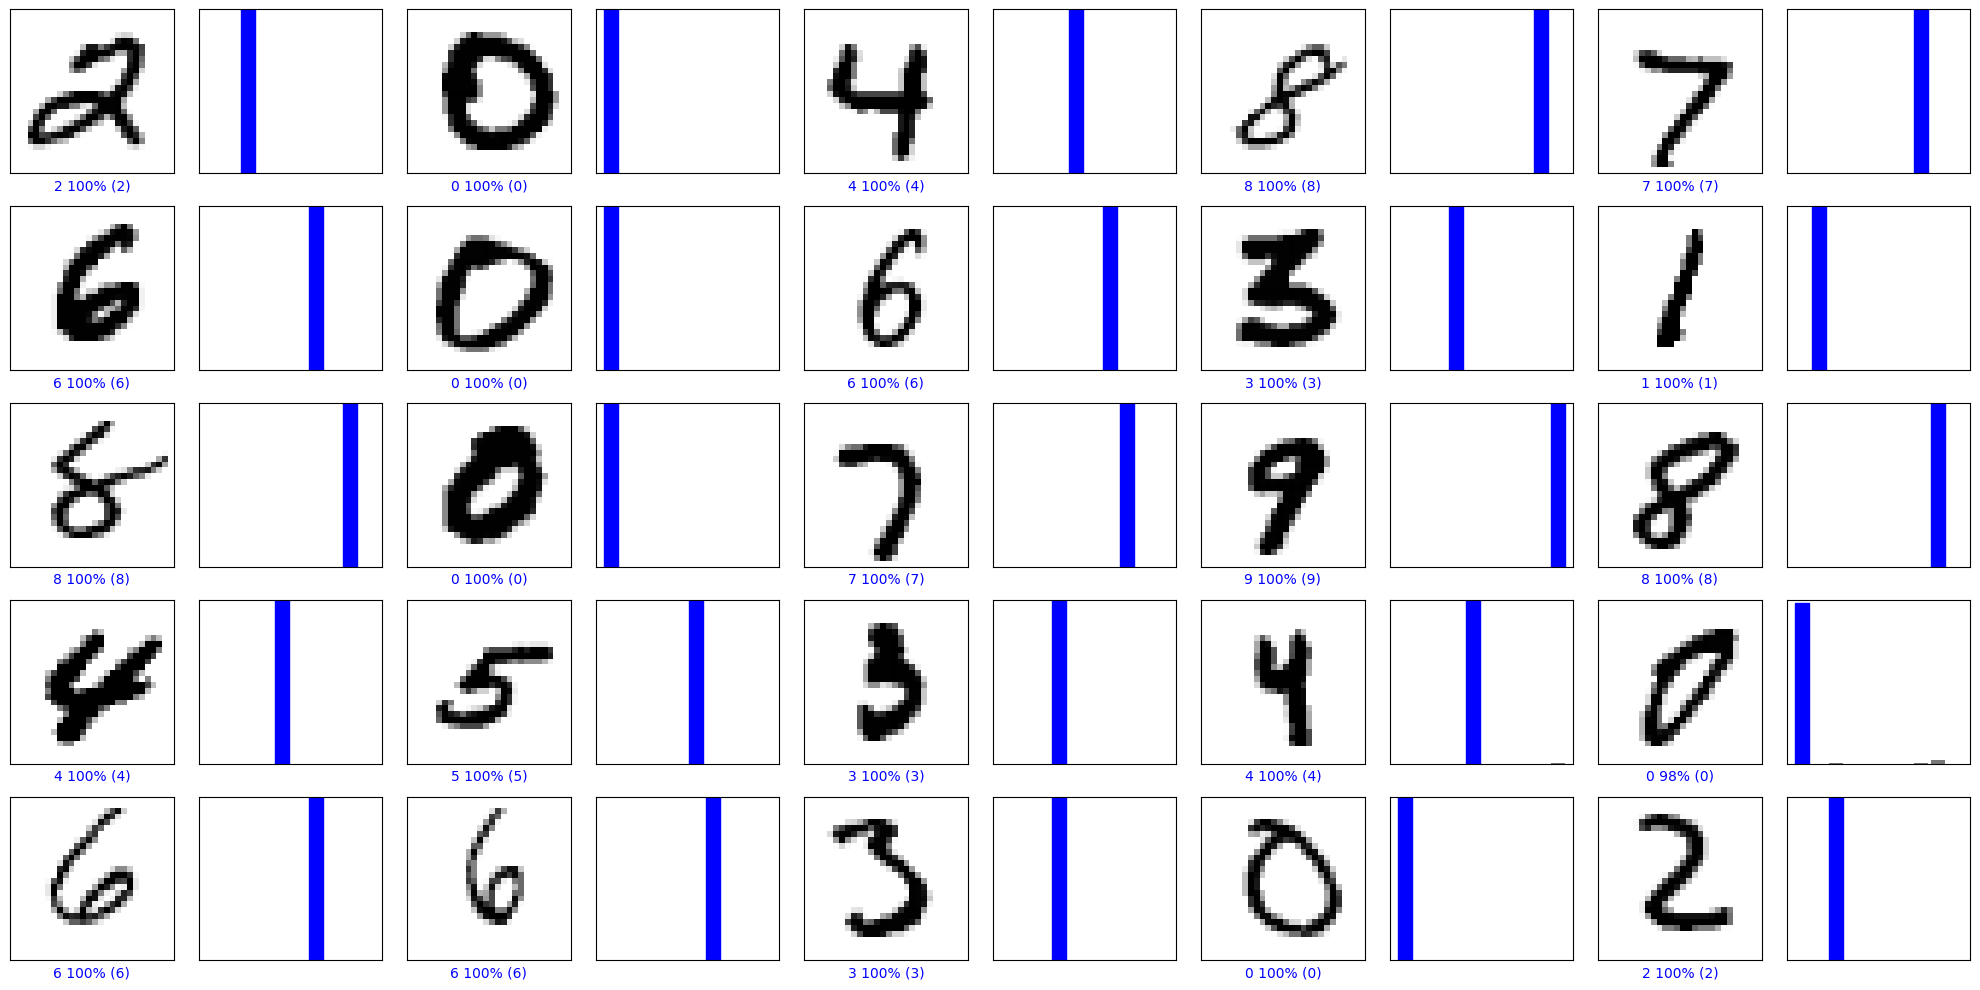

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mostrar predicciones con aciertos (azul) y errores (rojo)
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()
    predicciones = modelo.predict(imagenes_prueba)

    def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
        arr_prediccion = arr_predicciones[i]
        etiqueta_real = etiquetas_reales[i]
        img = imagenes[i]

        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(img[..., 0], cmap=plt.cm.binary)

        etiqueta_prediccion = np.argmax(arr_prediccion)
        color = 'blue' if etiqueta_prediccion == etiqueta_real else 'red'

        plt.xlabel(f"{nombres_clases[etiqueta_prediccion]} {100*np.max(arr_prediccion):2.0f}% ({nombres_clases[etiqueta_real]})", color=color)

    def graficar_valor_arreglo(i, arr_predicciones, etiquetas_reales):
        arr_prediccion = arr_predicciones[i]
        etiqueta_real = etiquetas_reales[i]

        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        grafica = plt.bar(range(10), arr_prediccion, color="#777777")
        plt.ylim([0, 1])

        etiqueta_prediccion = np.argmax(arr_prediccion)
        grafica[etiqueta_prediccion].set_color('red')
        grafica[etiqueta_real].set_color('blue')

    # Configuración de la cuadrícula
    filas = 5
    columnas = 5
    num_imagenes = filas * columnas

    plt.figure(figsize=(2 * 2 * columnas, 2 * filas))

    for i in range(num_imagenes):
        # Imagen
        plt.subplot(filas, 2 * columnas, 2 * i + 1)
        graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)

        # Gráfico de barras de predicciones
        plt.subplot(filas, 2 * columnas, 2 * i + 2)
        graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

    plt.tight_layout()
    plt.show()

### Visualización de predicciones
Este código toma un lote de imágenes de prueba, realiza predicciones con el modelo y luego visualiza tanto las imágenes como sus predicciones. Si la predicción es correcta, la etiqueta se muestra en azul; si es incorrecta, en rojo.